# UPI Transaction Analytics: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore historical UPI transaction data, identify trends, uncover patterns, and generate insights that help explain the growth of digital payments in India.

## Key Questions

1. How has UPI grown since launch?
2. How has transaction value changed over time?
3. How has bank participation evolved?
4. Are there distinct phases of UPI adoption?
5. What major events may have influenced growth?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')

In [2]:
upi = pd.read_csv("../data/processed/upi_master.csv")
upi.tail(n=25)

,Month,Banks,Volume_Mn,Value_Cr
97,2024-05-01,598,14035.84,2044937.05
98,2024-06-01,602,13885.14,2007081.20
99,2024-07-01,605,14435.55,2064292.41
100,2024-08-01,608,14963.05,2060735.57
101,2024-09-01,622,15041.75,2063994.71
102,2024-10-01,632,16584.97,2349821.46
103,2024-11-01,637,15482.02,2155187.40
104,2024-12-01,641,16730.01,2324699.91
105,2025-01-01,647,16996.00,2348037.12
106,2025-02-01,653,16106.19,2196481.69


In [3]:
upi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Month      122 non-null    object 
 1   Banks      122 non-null    int64  
 2   Volume_Mn  122 non-null    float64
 3   Value_Cr   122 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.9+ KB


In [4]:
upi['Month'] = pd.to_datetime(upi['Month'])

In [5]:
upi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Month      122 non-null    datetime64[ns]
 1   Banks      122 non-null    int64         
 2   Volume_Mn  122 non-null    float64       
 3   Value_Cr   122 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 3.9 KB


# Question 1

How has UPI transaction volume evolved since launch?

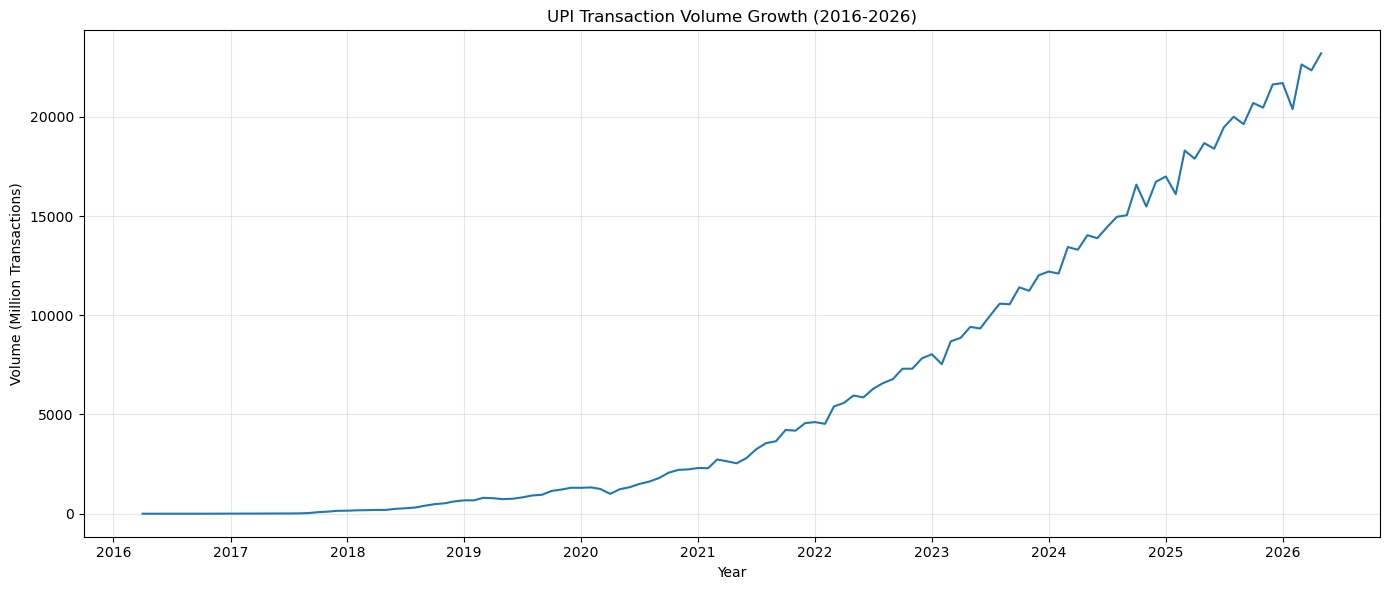

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    upi['Month'],
    upi['Volume_Mn']
)

plt.title('UPI Transaction Volume Growth (2016-2026)')
plt.xlabel('Year')
plt.ylabel('Volume (Million Transactions)')

# Force every year label
years = range(2016, 2027)
plt.xticks(
    [pd.Timestamp(f'{year}-01-01') for year in years],
    years
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation: UPI Transaction Volume Growth

The UPI ecosystem experienced three distinct growth phases between 2016 and 2026.

#### Phase 1: Early Adoption (2016 – Q1 2020)
- Transaction volume remained relatively low but grew steadily.
- Growth was gradual as consumers, merchants, and banks became familiar with the UPI ecosystem.
- The adoption curve during this period appears mostly linear.

#### Phase 2: Pandemic-Driven Acceleration (Q2 2020 – 2021)
- Following the COVID-19 lockdown in India, transaction volume increased at a significantly faster rate.
- The trend shifted from gradual growth to rapid acceleration.
- This period suggests a major behavioral shift toward digital and contactless payments.

#### Phase 3: Mass Adoption & Ecosystem Expansion (2022 – 2026)
- Growth continued even after pandemic restrictions were lifted.
- The sustained upward trend indicates that digital payment adoption became a permanent habit rather than a temporary response to COVID-19.
- UPI evolved from an emerging payment platform into a core component of India's financial infrastructure.

### Key Insight

The COVID-19 period appears to be a major inflection point in UPI adoption. While UPI was already growing before 2020, the pandemic coincided with a substantial increase in the rate of adoption, after which growth continued at a much higher scale.


# Question 2

Did transaction value grow at the same rate as transaction volume?

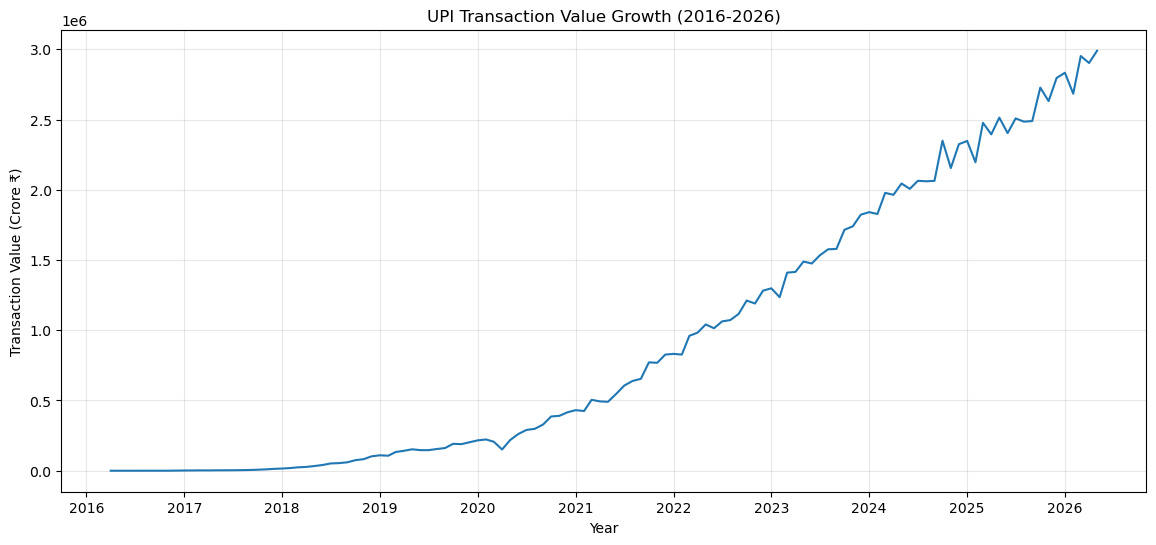

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    upi['Month'],
    upi['Value_Cr']
)

plt.title('UPI Transaction Value Growth (2016-2026)')
plt.xlabel('Year')
plt.ylabel('Transaction Value (Crore ₹)')

years = range(2016, 2027)
plt.xticks(
    [pd.Timestamp(f'{year}-01-01') for year in years],
    years
)

plt.grid(alpha=0.3)

plt.show()

# Question 3

Are people making larger or smaller UPI transactions over time?

In [8]:
upi['Avg_Transaction_Value'] = (
    upi['Value_Cr'] * 10 /
    upi['Volume_Mn']
)

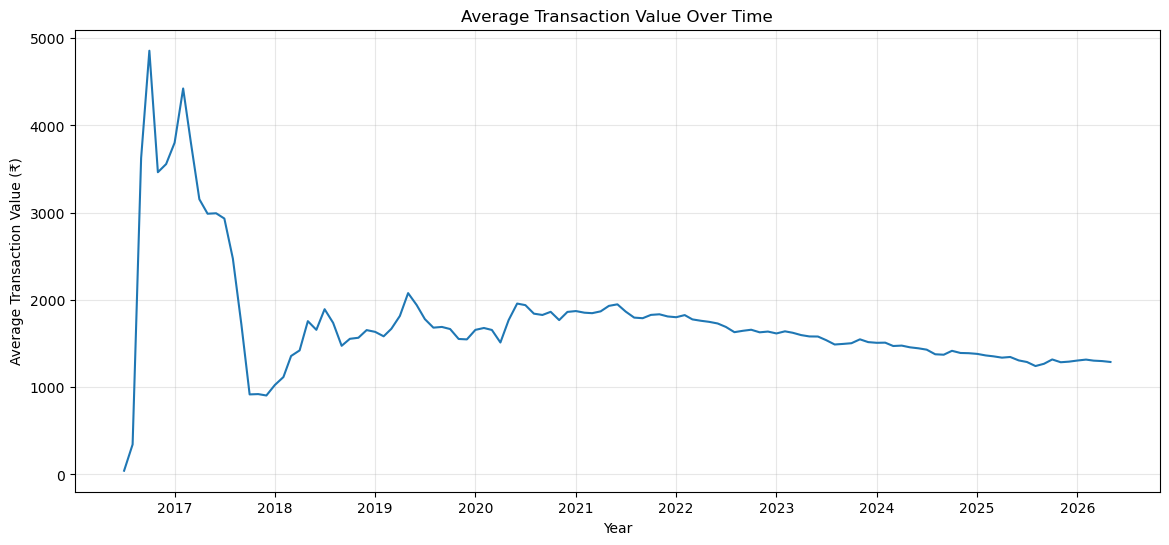

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    upi['Month'],
    upi['Avg_Transaction_Value']
)

plt.title('Average Transaction Value Over Time')
plt.xlabel('Year')
plt.ylabel('Average Transaction Value (₹)')

plt.grid(alpha=0.3)

plt.show()

## Observation: Average Transaction Value (UPI Trends)

- The average transaction value increased during the initial years of UPI adoption, reaching a peak around 2017. This suggests that early users may have relied on UPI for relatively larger transactions while the ecosystem was still developing.

- A noticeable decline is observed during 2018, after which the average transaction value stabilizes within a narrower range.

- Despite exponential growth in total transaction volume, the average transaction value has remained relatively stable since 2018, with only minor fluctuations over time.

- This indicates that UPI's expansion has been driven primarily by an increase in the number of transactions and users rather than a substantial increase in the size of individual transactions.

- The stability of the average transaction value suggests that UPI has become deeply integrated into everyday payment behavior, supporting a broad range of routine transactions at scale.

### Key Insight

While UPI transaction volume and total transaction value have grown dramatically over the years, the average transaction value has remained relatively stable. This suggests that UPI's success is largely driven by increasing user adoption and transaction frequency, highlighting its evolution into a mainstream payment method for everyday transactions across India.

# Question 4

How has UPI's growth trajectory changed across different adoption phases?

In [10]:
conditions = [
    upi['Month'] < '2020-03-01',
    (upi['Month'] >= '2020-03-01') & (upi['Month'] < '2022-01-01'),
    upi['Month'] >= '2022-01-01'
]

labels = [
    'Early Adoption',
    'COVID Acceleration',
    'Mass Adoption'
]

upi['Phase'] = np.select(conditions, labels, default='Other')

In [11]:
phase_volume = (
    upi.groupby('Phase')['Volume_Mn']
    .mean()
    .reset_index()
)

phase_volume

,Phase,Volume_Mn
0,COVID Acceleration,2499.760455
1,Early Adoption,374.390851
2,Mass Adoption,13254.016792


In [12]:
upi[['Month','Phase']].head()

,Month,Phase
0,2016-04-01,Early Adoption
1,2016-05-01,Early Adoption
2,2016-06-01,Early Adoption
3,2016-07-01,Early Adoption
4,2016-08-01,Early Adoption


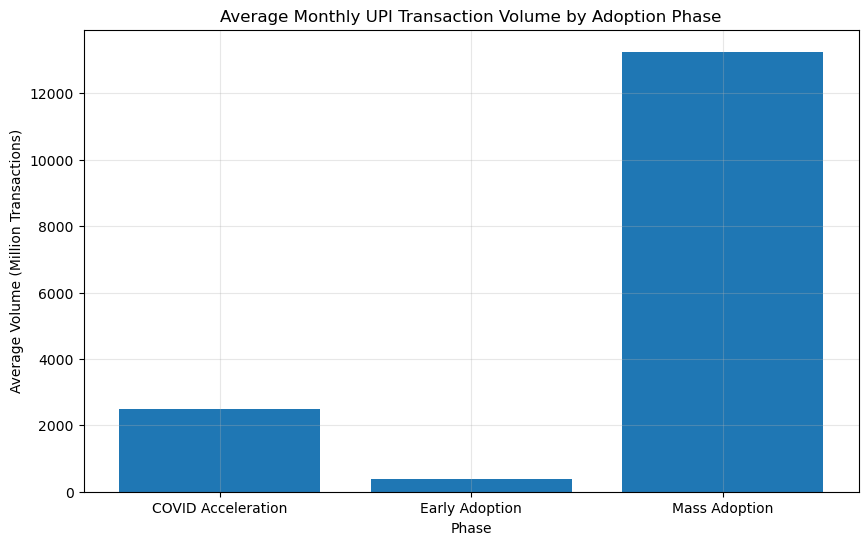

In [13]:
plt.figure(figsize=(10,6))

plt.bar(
    phase_volume['Phase'],
    phase_volume['Volume_Mn']
)

plt.title('Average Monthly UPI Transaction Volume by Adoption Phase')
plt.xlabel('Phase')
plt.ylabel('Average Volume (Million Transactions)')

plt.grid(alpha=0.3)

plt.show()

# Question 5: CAGR Analysis



In [14]:
cagr_data  = upi[upi['Volume_Mn'] > 0].copy()

cagr_data

,Month,Banks,Volume_Mn,Value_Cr,Avg_Transaction_Value,Phase
3,2016-07-01,21,0.09,0.38,42.222222,Early Adoption
4,2016-08-01,21,0.09,3.09,343.333333,Early Adoption
5,2016-09-01,25,0.09,32.64,3626.666667,Early Adoption
6,2016-10-01,26,0.10,48.57,4857.000000,Early Adoption
7,2016-11-01,30,0.29,100.46,3464.137931,Early Adoption
...,...,...,...,...,...,...
117,2026-01-01,691,21703.44,2833481.22,1305.544752,Mass Adoption
118,2026-02-01,694,20394.18,2684229.29,1316.174168,Mass Adoption
119,2026-03-01,705,22641.11,2952542.05,1304.062411,Mass Adoption
120,2026-04-01,713,22346.80,2902988.05,1299.062080,Mass Adoption


In [15]:
start_volume = cagr_data['Volume_Mn'].iloc[0]
end_volume = cagr_data['Volume_Mn'].iloc[-1]

print(start_volume)
print(end_volume)

0.09
23201.93


In [16]:
num_years = (cagr_data['Month'].max() - cagr_data['Month'].min()).days/365.25

In [17]:
cagr = (
    (end_volume / start_volume)
    ** (1 / num_years)
    - 1
) * 100

print(f"CAGR: {cagr:.2f}%")

CAGR: 255.14%


### Observation: Compound Annual Growth Rate (CAGR)

UPI transaction volume increased from 0.09 million transactions in July 2016 to over 23,201 million transactions by May 2026.

The compound annual growth rate (CAGR) over this period was approximately **255.14%**.

This exceptionally high growth rate reflects the rapid adoption of UPI across India and highlights its transformation from an emerging payment platform into one of the world's largest digital payment ecosystems.

It should be noted that the CAGR is influenced by the extremely small starting transaction volume during the early adoption phase. Therefore, the metric is best interpreted as an indicator of long-term growth rather than a representation of annual performance.

# Question 6

Has transaction growth outpaced bank participation growth?

In [21]:
upi['Transactions_Per_Bank'] = upi['Volume_Mn']/upi['Banks']

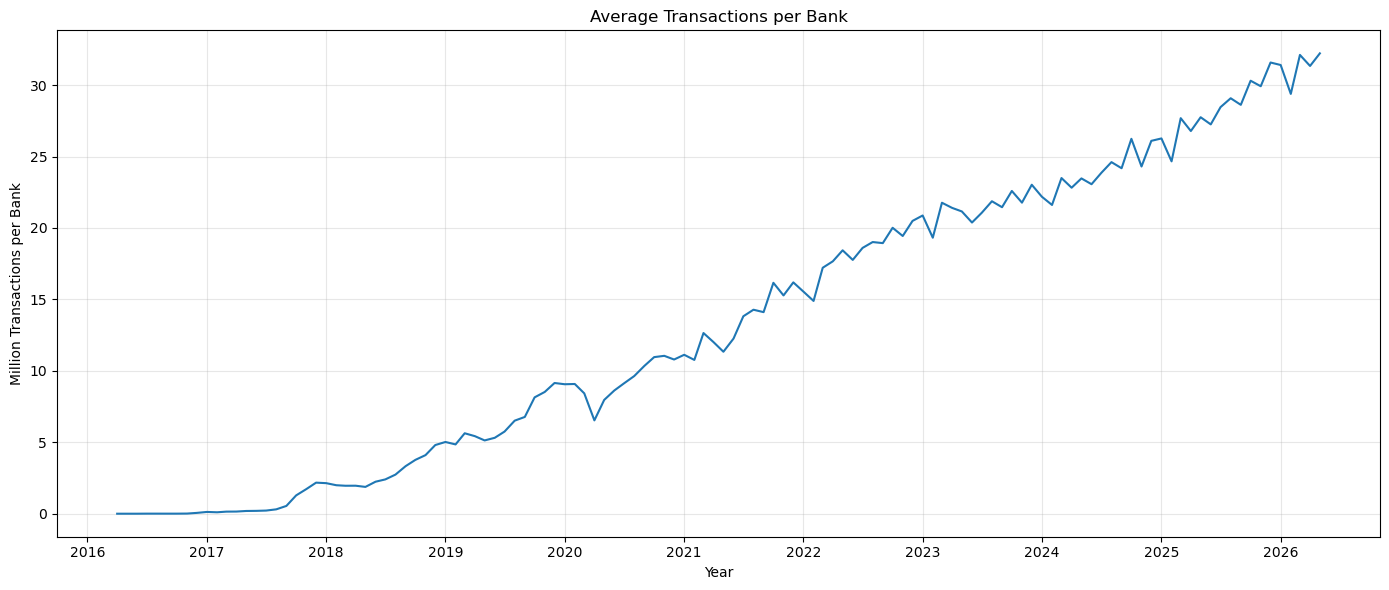

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    upi['Month'],
    upi['Transactions_Per_Bank']
)

plt.title('Average Transactions per Bank')
plt.xlabel('Year')
plt.ylabel('Million Transactions per Bank')

years = range(2016, 2027)

plt.xticks(
    [pd.Timestamp(f'{year}-01-01') for year in years],
    years
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation: Transactions per Participating Bank

The average number of transactions processed per participating bank remained relatively low and stable during the initial adoption phase of UPI (2016–2018).

From mid-2018 onwards, transactions per bank increased steadily over time. This indicates that transaction growth began to outpace the growth in the number of participating banks.

The sustained increase suggests that UPI adoption was increasingly driven by higher transaction activity within the existing banking network rather than solely by the addition of new banks.

### Key Insight

As the UPI ecosystem matured, growth became less dependent on expanding bank participation and more dependent on increasing consumer usage. This indicates strengthening network effects, where existing users and institutions generated progressively higher transaction volumes.

# EDA Summary

## Key Findings

1. UPI transaction volume experienced exponential growth between 2016 and 2026.

2. Transaction value increased alongside transaction volume, indicating broader adoption of digital payments.

3. Average transaction value stabilized after 2018, suggesting that growth was driven by increasing transaction frequency rather than larger transaction sizes.

4. Three distinct adoption phases were identified:
   - Early Adoption
   - COVID Acceleration
   - Mass Adoption

5. UPI transaction volume achieved a CAGR of approximately 255%, reflecting one of the fastest digital payment adoption trajectories in India.

6. Transactions per participating bank increased steadily over time, indicating that user adoption and transaction activity grew faster than bank participation.